In [1]:
import xarray as xr
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
df_core = pd.read_csv("../outputs/finn_pm25_daily_core.csv", index_col="date", parse_dates=True)

In [3]:
df = pd.read_csv("../outputs/combined_conaf_fire_records.csv", 
                 encoding="utf-8",
                 sep=",",
                 on_bad_lines="skip",
                 low_memory=False)
print(df["Inicio"].head(10))

0    2018-10-03 16:26:00
1    2018-10-14 15:12:00
2    2018-10-14 15:27:00
3    2018-10-16 18:31:00
4    2018-10-21 11:52:00
5    2018-10-22 10:00:00
6    2018-10-22 13:52:00
7    2018-10-22 16:44:00
8    2018-10-24 18:22:00
9    2018-10-26 17:18:00
Name: Inicio, dtype: object


In [4]:
print(df["Región"].unique())

['Biobío' 'Ñuble' 'Araucanía']


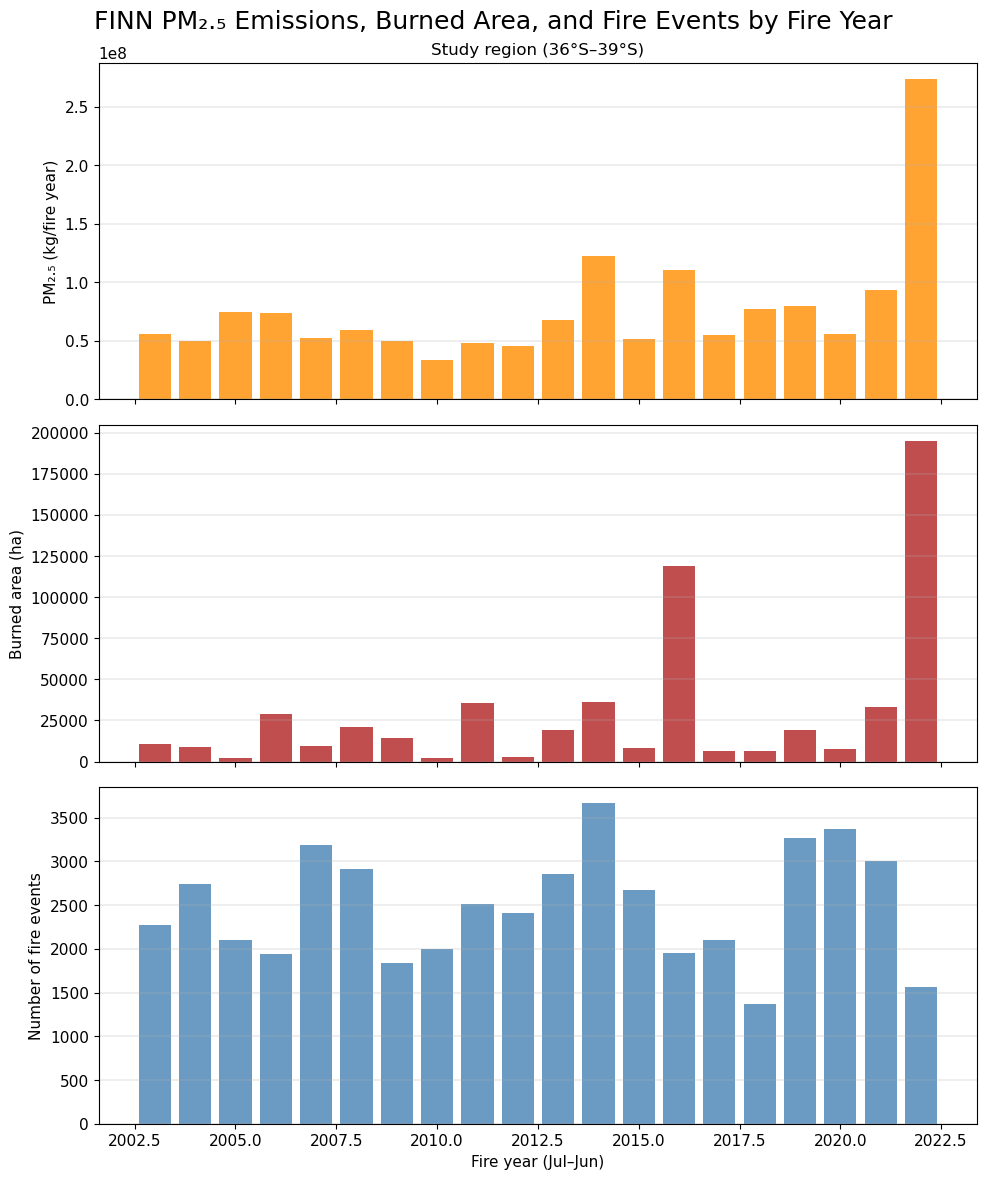

In [5]:
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
})

# Parse out dates
df["Inicio"] = pd.to_datetime(df["Inicio"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Assign fire year (Jul-Jun convention)
df["fire_year"] = df["Inicio"].apply(
    lambda d: d.year if d.month >= 7 else d.year - 1
)

# Filter to study region 
core_regions = ["Ñuble", "Biobío", "La Araucanía"]
df_core_conaf = df[df["Región"].isin(core_regions)].copy()

# Clean burned area column
df_core_conaf["Superficie total Has"] = pd.to_numeric(df_core_conaf["Superficie total Has"], errors="coerce")

# Annual aggregations
conaf_core = df_core_conaf.groupby("fire_year").agg(
    burned_area=("Superficie total Has", "sum"),
    n_events=("Inicio", "count")
).reset_index()

# Annual FINN emissions (Jul-Jun fire year)
df_core.index = pd.to_datetime(df_core.index)
df_core["fire_year"] = df_core.index.map(
    lambda d: d.year if d.month >= 7 else d.year - 1
)
finn_core_annual = df_core.groupby("fire_year")["PM25_kg_day_sum"].sum().reset_index()
finn_core_annual.rename(columns={"PM25_kg_day_sum": "PM25_kg_annual"}, inplace=True)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

merged = finn_core_annual.merge(conaf_core, on="fire_year", how="inner")

# Row 0: FINN PM2.5 annual total
axes[0].bar(merged["fire_year"], merged["PM25_kg_annual"], color="darkorange", alpha=0.8)
axes[0].set_title("Study region (36°S–39°S)")
axes[0].set_ylabel("PM₂.₅ (kg/fire year)")
axes[0].grid(True, linewidth=0.3, axis="y")

# Row 1: Total burned area
axes[1].bar(merged["fire_year"], merged["burned_area"], color="firebrick", alpha=0.8)
axes[1].set_ylabel("Burned area (ha)")
axes[1].grid(True, linewidth=0.3, axis="y")

# Row 2: Number of events
axes[2].bar(merged["fire_year"], merged["n_events"], color="steelblue", alpha=0.8)
axes[2].set_ylabel("Number of fire events")
axes[2].set_xlabel("Fire year (Jul–Jun)")
axes[2].grid(True, linewidth=0.3, axis="y")

fig.suptitle("FINN PM₂.₅ Emissions, Burned Area, and Fire Events by Fire Year", fontsize=18)
plt.tight_layout()
plt.savefig("../outputs/finn_pm25_burned_area_events.png", dpi=400)
plt.show()

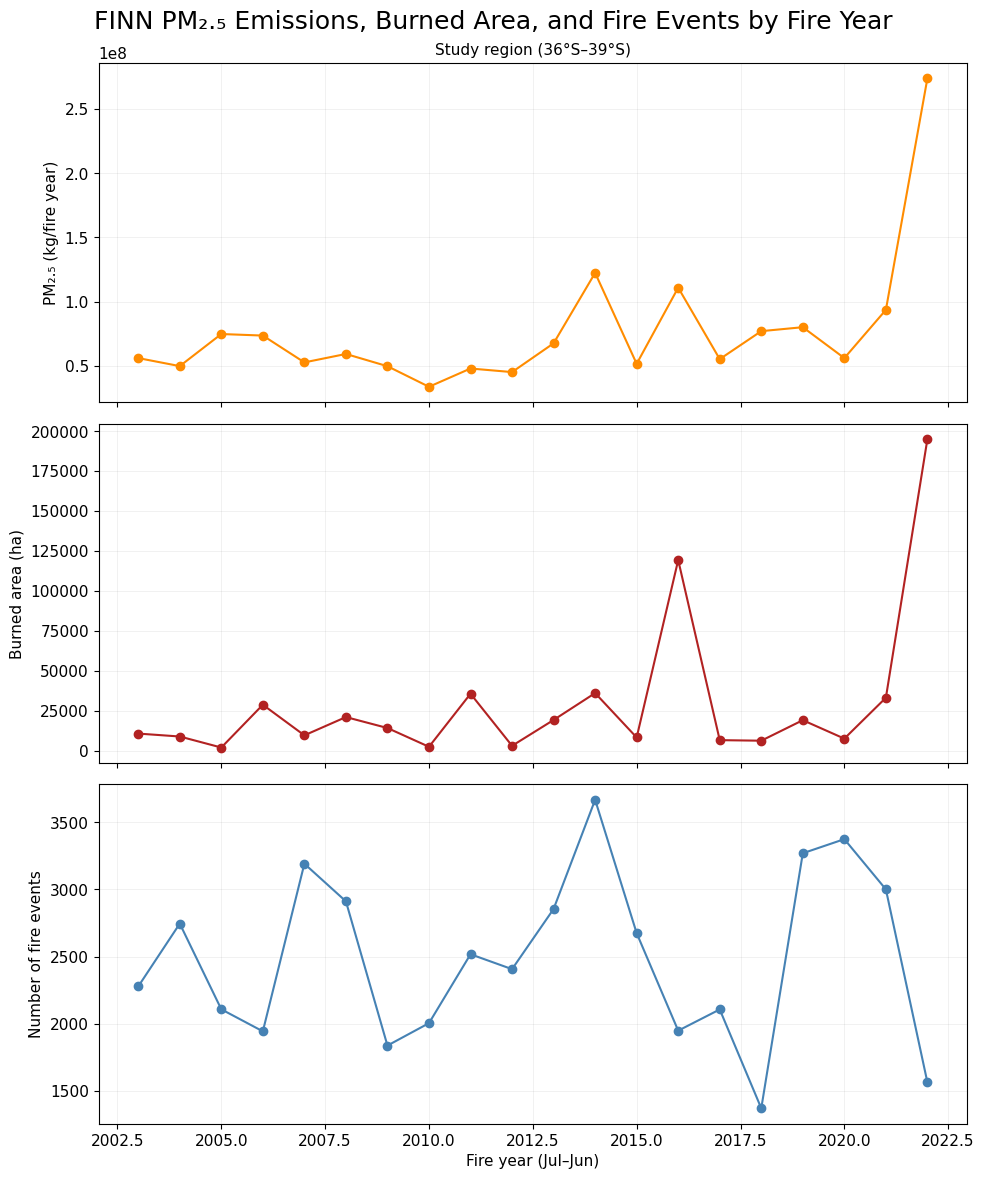

In [6]:
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
})

# Parse out dates
df["Inicio"] = pd.to_datetime(df["Inicio"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Assign fire year (Jul-Jun convention)
df["fire_year"] = df["Inicio"].apply(
    lambda d: d.year if d.month >= 7 else d.year - 1
)

# Filter to core region (Ñuble, Biobío, Araucanía)
core_regions = ["Ñuble", "Biobío", "La Araucanía"]
df_core_conaf = df[df["Región"].isin(core_regions)].copy()

# Clean burned area column
df_core_conaf["Superficie total Has"] = pd.to_numeric(df_core_conaf["Superficie total Has"], errors="coerce")

# Annual aggregations
conaf_core = df_core_conaf.groupby("fire_year").agg(
    burned_area=("Superficie total Has", "sum"),
    n_events=("Inicio", "count")
).reset_index()

# Annual FINN emissions (Jul-Jun fire year)
df_core.index = pd.to_datetime(df_core.index)
df_core["fire_year"] = df_core.index.map(
    lambda d: d.year if d.month >= 7 else d.year - 1
)
finn_core_annual = df_core.groupby("fire_year")["PM25_kg_day_sum"].sum().reset_index()
finn_core_annual.rename(columns={"PM25_kg_day_sum": "PM25_kg_annual"}, inplace=True)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

merged = finn_core_annual.merge(conaf_core, on="fire_year", how="inner")

# Row 0: FINN PM2.5 annual total
axes[0].plot(merged["fire_year"], merged["PM25_kg_annual"], marker="o", color="darkorange", linewidth=1.5)
axes[0].set_title("Study region (36°S–39°S)")
axes[0].set_ylabel("PM₂.₅ (kg/fire year)")
axes[0].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)

# Row 1: Total burned area
axes[1].plot(merged["fire_year"], merged["burned_area"], marker="o", color="firebrick", linewidth=1.5)
axes[1].set_ylabel("Burned area (ha)")
axes[1].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)

# Row 2: Number of events
axes[2].plot(merged["fire_year"], merged["n_events"], marker="o", color="steelblue", linewidth=1.5)
axes[2].set_ylabel("Number of fire events")
axes[2].set_xlabel("Fire year (Jul–Jun)")
axes[2].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)

fig.suptitle("FINN PM₂.₅ Emissions, Burned Area, and Fire Events by Fire Year", fontsize=18)
plt.tight_layout()
plt.savefig("../outputs/finn_pm25_burned_area_events_line.png", dpi=400)
plt.show()

In [7]:
import pymannkendall as mk

for label, finn_df in [("Core", finn_core_annual)]:
    result = mk.original_test(finn_df["PM25_kg_annual"])
    print(f"\n--- {label} region ---")
    print(f"  Trend      : {result.trend}")
    print(f"  p-value    : {result.p:.4f}")
    print(f"  Sen's slope: {result.slope:.4e} kg/fire year")
    print(f"  Tau        : {result.Tau:.4f}")


--- Core region ---
  Trend      : no trend
  p-value    : 0.0744
  Sen's slope: 1.8563e+06 kg/fire year
  Tau        : 0.2947


In [8]:
from scipy import stats
import numpy as np

# Merge all variables into one dataframe for each region
for label, finn_df, conaf_df in [
    ("Core", finn_core_annual, conaf_core), 
]:
    merged = finn_df.merge(conaf_df, on="fire_year", how="inner")
    
    pairs = [
        ("PM25_kg_annual", "burned_area",  "PM2.5 emissions vs burned area"),
        ("PM25_kg_annual", "n_events",     "PM2.5 emissions vs number of events"),
        ("burned_area",    "n_events",     "Burned area vs number of events"),
    ]
    
    print(f"\n{'='*55}")
    print(f"  {label} region (n={len(merged)})")
    print(f"{'='*55}")
    
    for x_col, y_col, description in pairs:
        x = merged[x_col].values
        y = merged[y_col].values
        
        # Pearson
        r_p, p_p = stats.pearsonr(x, y)
        # Spearman
        r_s, p_s = stats.spearmanr(x, y)
        
        print(f"\n  {description}")
        print(f"    Pearson  r={r_p:.3f}, p={p_p:.4f}")
        print(f"    Spearman r={r_s:.3f}, p={p_s:.4f}")


  Core region (n=20)

  PM2.5 emissions vs burned area
    Pearson  r=0.906, p=0.0000
    Spearman r=0.547, p=0.0125

  PM2.5 emissions vs number of events
    Pearson  r=-0.223, p=0.3451
    Spearman r=0.032, p=0.8949

  Burned area vs number of events
    Pearson  r=-0.311, p=0.1818
    Spearman r=0.102, p=0.6679


## Adding in FSL

In [9]:
fsl_m1 = pd.read_csv("../outputs/method1_results.csv")
fsl_m2 = pd.read_csv("../outputs/method2_results.csv")
fsl_m3 = pd.read_csv("../outputs/method3_percell_results.csv")

print(fsl_m1.head())
print(fsl_m2.head())
print(fsl_m3.head())

   fire_year  first_ignition_date   last_ignition_date last_extinction_date  \
0  2002-2003  2002-07-15 10:15:00  2003-06-06 16:33:00  2003-06-06 18:09:00   
1  2003-2004  2003-08-24 22:00:00  2004-05-20 10:00:00  2004-05-31 20:00:00   
2  2004-2005  2004-08-17 18:00:00  2005-05-24 11:32:00  2005-05-24 12:21:00   
3  2005-2006  2005-07-25 17:40:00  2006-05-15 12:36:00  2006-05-15 21:00:00   
4  2006-2007  2006-09-17 16:31:00  2007-06-04 18:00:00  2007-06-05 07:00:00   

   season_length_days fire_year_start  first_day  last_ignition_day  last_day  
0                 326      2002-07-01         14                340       340  
1                 280      2003-07-01         54                324       335  
2                 279      2004-07-01         47                327       327  
3                 294      2005-07-01         24                318       318  
4                 260      2006-07-01         78                338       339  
                            file fire_year_st

In [10]:
# Inspect
print(finn_core_annual.head())
print(finn_core_annual["fire_year"].dtype)
print(fsl_m1.head())
print(fsl_m2.head())
print(fsl_m3.head())

# Standardise fire_year to integer start year
fsl_m1["fire_year"] = fsl_m1["fire_year"].str.split("-").str[0].astype(int)
fsl_m2["fire_year"] = fsl_m2["fire_year_start"].str.split("-").str[0].astype(int)
fsl_m3["fire_year"] = fsl_m3["fire_year"].str.split("-").str[0].astype(int)

# Confirm dtypes
print(finn_core_annual["fire_year"].dtype)
print(fsl_m1["fire_year"].dtype)
print(fsl_m2["fire_year"].dtype)
print(fsl_m3["fire_year"].dtype)

# Merge
merged_fsl = finn_core_annual.copy()
merged_fsl = merged_fsl.merge(fsl_m1[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "fsl_m1"}), on="fire_year", how="inner")
merged_fsl = merged_fsl.merge(fsl_m2[["fire_year", "season_length_days"]].rename(columns={"season_length_days": "fsl_m2"}), on="fire_year", how="inner")
merged_fsl = merged_fsl.merge(fsl_m3[["fire_year", "fsl_p90_median"]].rename(columns={"fsl_p90_median": "fsl_m3"}), on="fire_year", how="inner")

print(merged_fsl.head())
print(merged_fsl.shape)

   fire_year  PM25_kg_annual
0       2003    5.615569e+07
1       2004    4.990856e+07
2       2005    7.486905e+07
3       2006    7.367198e+07
4       2007    5.279835e+07
int64
   fire_year  first_ignition_date   last_ignition_date last_extinction_date  \
0  2002-2003  2002-07-15 10:15:00  2003-06-06 16:33:00  2003-06-06 18:09:00   
1  2003-2004  2003-08-24 22:00:00  2004-05-20 10:00:00  2004-05-31 20:00:00   
2  2004-2005  2004-08-17 18:00:00  2005-05-24 11:32:00  2005-05-24 12:21:00   
3  2005-2006  2005-07-25 17:40:00  2006-05-15 12:36:00  2006-05-15 21:00:00   
4  2006-2007  2006-09-17 16:31:00  2007-06-04 18:00:00  2007-06-05 07:00:00   

   season_length_days fire_year_start  first_day  last_ignition_day  last_day  
0                 326      2002-07-01         14                340       340  
1                 280      2003-07-01         54                324       335  
2                 279      2004-07-01         47                327       327  
3                 294    

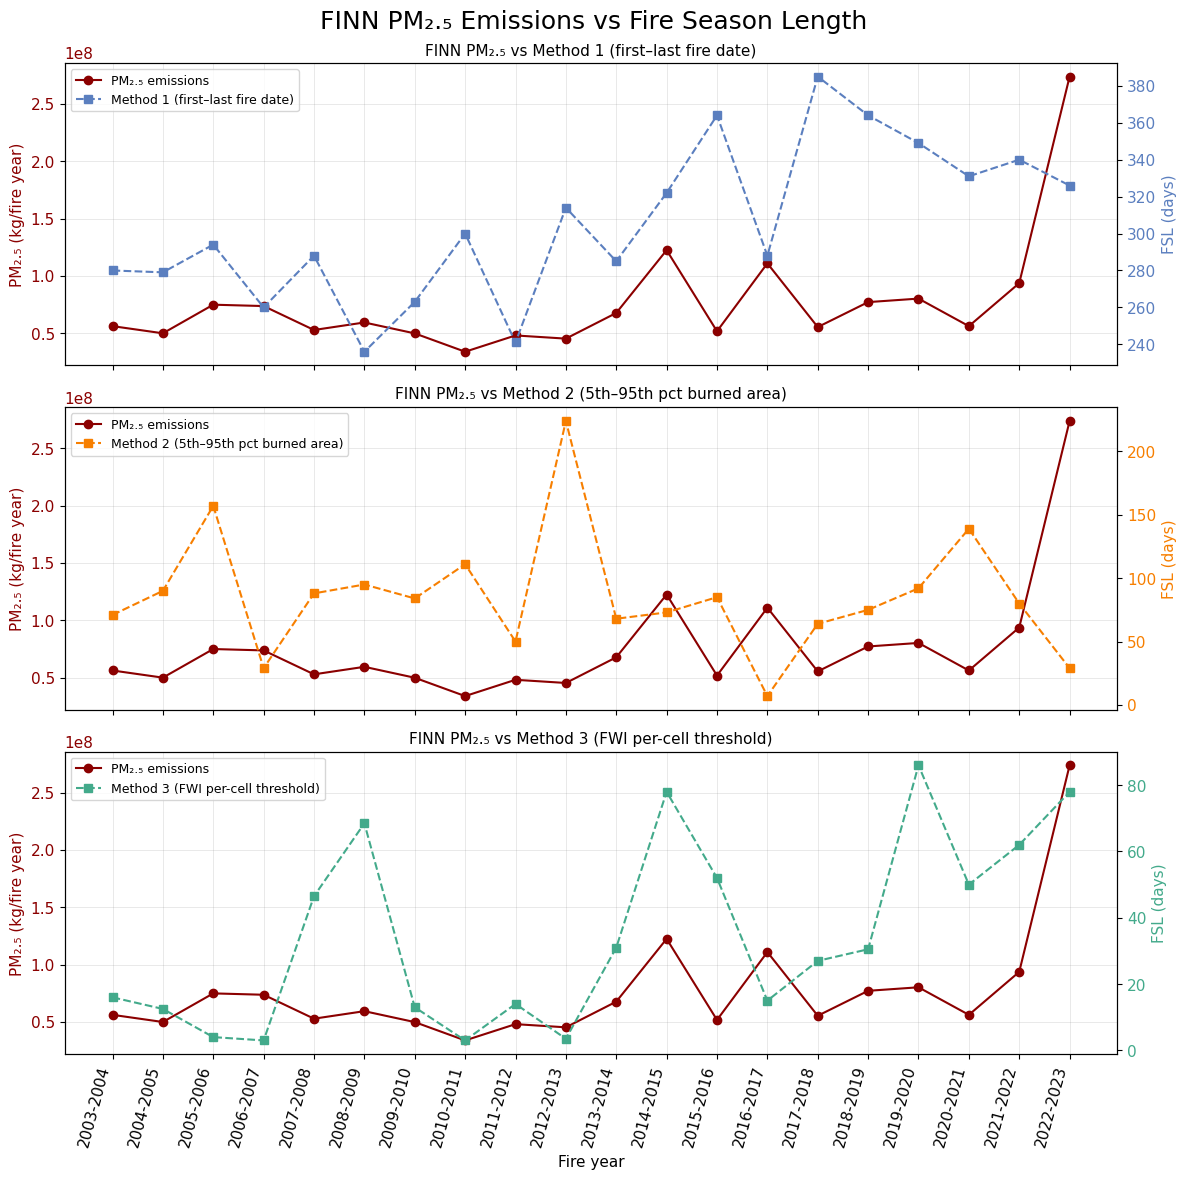

In [11]:
# restrict to the 2002/03 to 2022/23 fire seasons
merged_fsl_2002 = merged_fsl[
    (merged_fsl["fire_year"] >= 2002) & (merged_fsl["fire_year"] <= 2022)
].copy()

# Plot: one row per FSL method, dual axis
fsl_methods = [
    ("fsl_m1", "Method 1 (first–last fire date)", "#5B7FBF"),
    ("fsl_m2", "Method 2 (5th–95th pct burned area)", "#F77F00"),
    ("fsl_m3", "Method 3 (FWI per-cell threshold)", "#43AA8B"),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for ax, (fsl_col, fsl_label, fsl_colour) in zip(axes, fsl_methods):
    ax2 = ax.twinx()
    ax.plot(merged_fsl_2002["fire_year"], merged_fsl_2002["PM25_kg_annual"],
            marker="o", color="darkred", linewidth=1.5, label="PM₂.₅ emissions")
    ax2.plot(merged_fsl_2002["fire_year"], merged_fsl_2002[fsl_col],
             marker="s", color=fsl_colour, linewidth=1.5, linestyle="--", label=fsl_label)
    ax.set_ylabel("PM₂.₅ (kg/fire year)", color="darkred")
    ax2.set_ylabel("FSL (days)", color=fsl_colour)
    ax.tick_params(axis="y", labelcolor="darkred")
    ax2.tick_params(axis="y", labelcolor=fsl_colour)
    ax.set_title(f"FINN PM₂.₅ vs {fsl_label}")
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

# build fire-year-range labels (e.g. 2002-2003) and show every year on the x-axis
x_vals = merged_fsl_2002["fire_year"].values
fire_year_labels = [f"{yr}-{yr+1}" for yr in x_vals]
axes[-1].set_xticks(x_vals)
axes[-1].set_xticklabels(fire_year_labels, rotation=75, ha="right")
axes[-1].set_xlabel("Fire year")

fig.suptitle("FINN PM₂.₅ Emissions vs Fire Season Length", fontsize=18)
plt.tight_layout()
plt.savefig("../outputs/fig9_finn_pm25_vs_fsl.png", dpi=400, bbox_inches="tight")
plt.show()

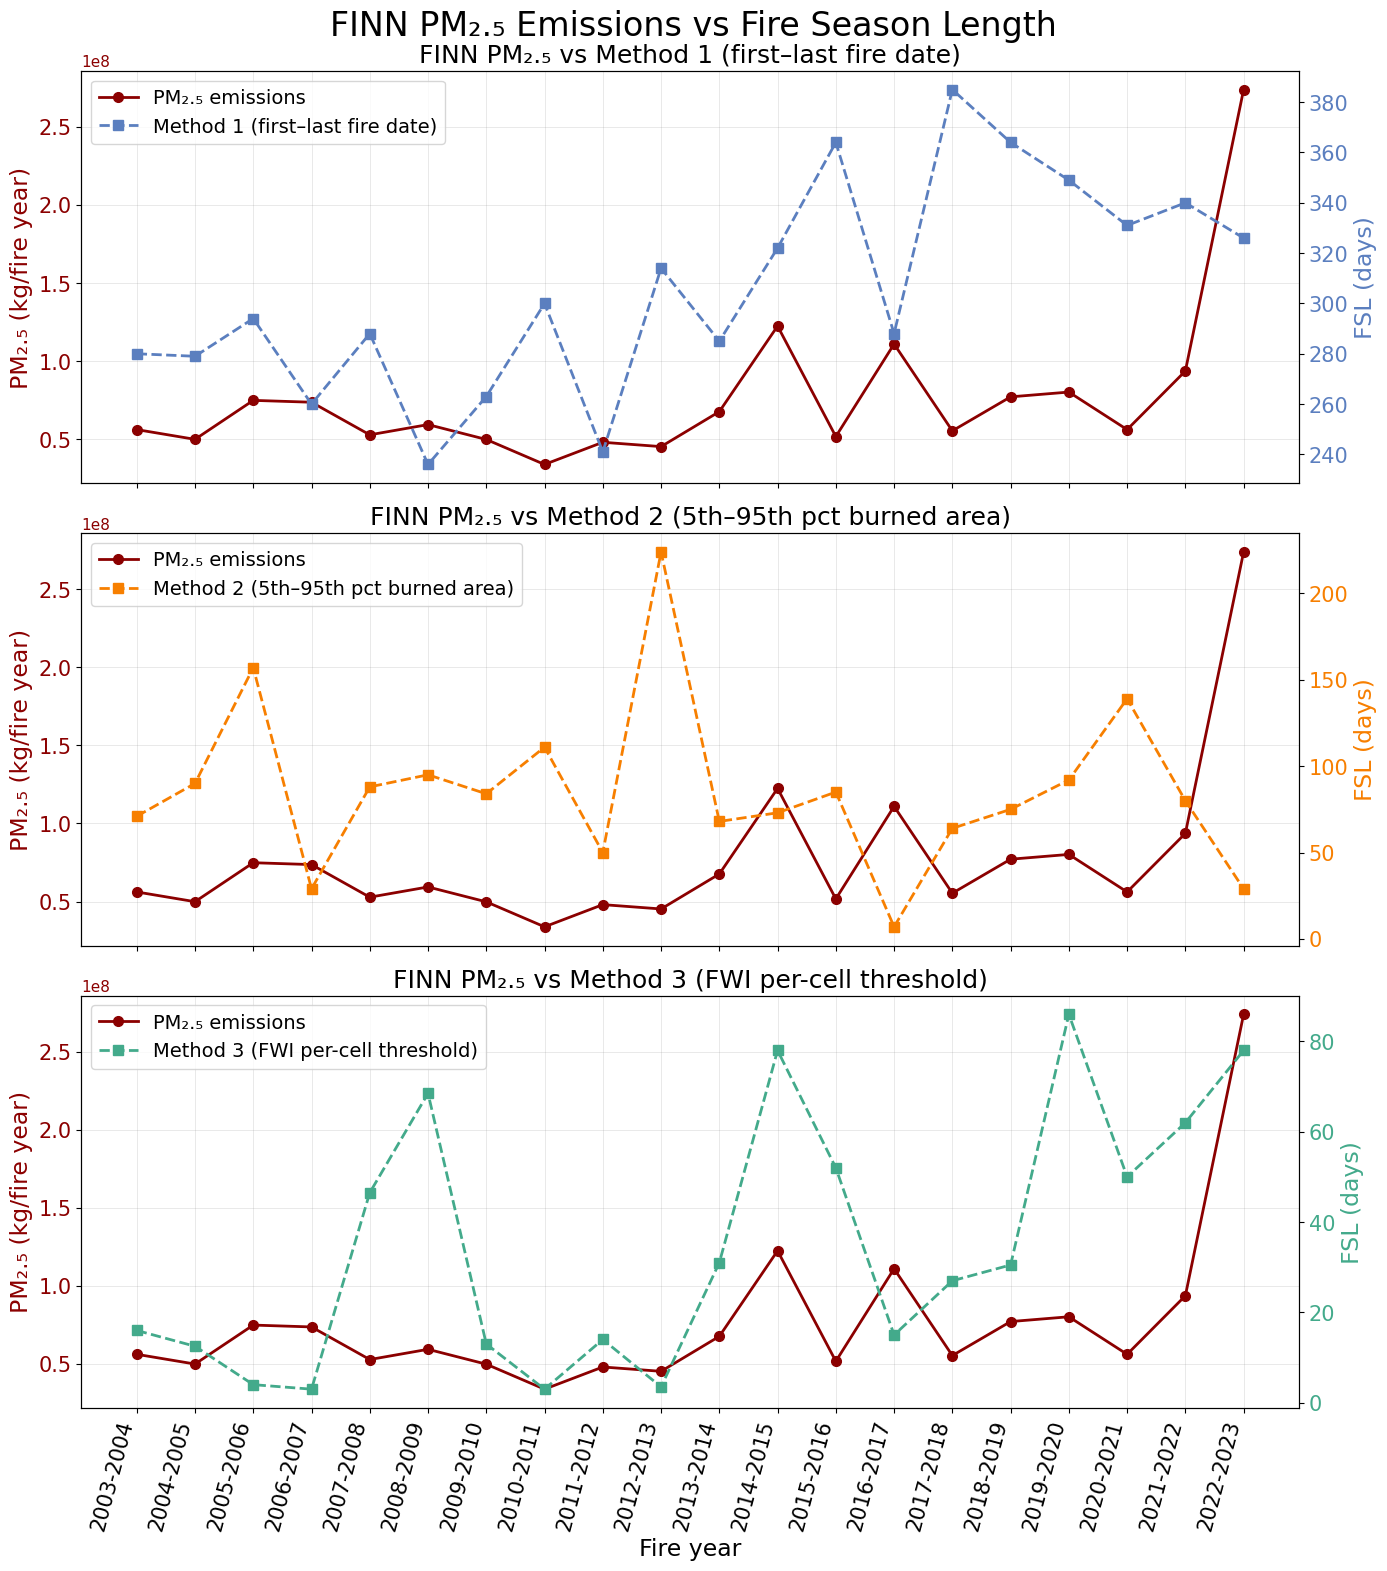

In [13]:
# Poster version of the FINN PM2.5 vs FSL figure 
poster_fontsize = {
    "suptitle": 24,
    "title": 18,
    "label": 17,
    "tick": 15,
    "legend": 14,
}

fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

for ax, (fsl_col, fsl_label, fsl_colour) in zip(axes, fsl_methods):
    ax2 = ax.twinx()
    ax.plot(merged_fsl_2002["fire_year"], merged_fsl_2002["PM25_kg_annual"],
            marker="o", color="darkred", linewidth=2, markersize=7, label="PM₂.₅ emissions")
    ax2.plot(merged_fsl_2002["fire_year"], merged_fsl_2002[fsl_col],
             marker="s", color=fsl_colour, linewidth=2, markersize=7, linestyle="--", label=fsl_label)
    ax.set_ylabel("PM₂.₅ (kg/fire year)", color="darkred", fontsize=poster_fontsize["label"])
    ax2.set_ylabel("FSL (days)", color=fsl_colour, fontsize=poster_fontsize["label"])
    ax.tick_params(axis="y", labelcolor="darkred", labelsize=poster_fontsize["tick"])
    ax2.tick_params(axis="y", labelcolor=fsl_colour, labelsize=poster_fontsize["tick"])
    ax.tick_params(axis="x", labelsize=poster_fontsize["tick"])
    ax.set_title(f"FINN PM₂.₅ vs {fsl_label}", fontsize=poster_fontsize["title"])
    ax.grid(True, which="major", axis="both", color="grey", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=poster_fontsize["legend"], loc="upper left")

# build fire-year-range labels (e.g. 2002-2003) and show every year on the x-axis
x_vals = merged_fsl_2002["fire_year"].values
fire_year_labels = [f"{yr}-{yr+1}" for yr in x_vals]
axes[-1].set_xticks(x_vals)
axes[-1].set_xticklabels(fire_year_labels, rotation=75, ha="right", fontsize=poster_fontsize["tick"])
axes[-1].set_xlabel("Fire year", fontsize=poster_fontsize["label"])

fig.suptitle("FINN PM₂.₅ Emissions vs Fire Season Length", fontsize=poster_fontsize["suptitle"])
plt.tight_layout()
plt.savefig("../outputs/fig9_finn_pm25_vs_fsl_poster.png", dpi=400, bbox_inches="tight")
plt.show()

In [12]:
# Correlations
from scipy import stats

for fsl_col, fsl_label in [
    ("fsl_m1", "Method 1 (first–last fire date)"),
    ("fsl_m2", "Method 2 (5th–95th pct burned area)"),
    ("fsl_m3", "Method 3 (FWI per-cell threshold)"),
]:
    x = merged_fsl["PM25_kg_annual"].values
    y = merged_fsl[fsl_col].values

    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)

    print(f"\n--- PM₂.₅ vs {fsl_label} ---")
    print(f"  Pearson  r={r_p:.3f}, p={p_p:.4f}")
    print(f"  Spearman r={r_s:.3f}, p={p_s:.4f}")


--- PM₂.₅ vs Method 1 (first–last fire date) ---
  Pearson  r=0.182, p=0.4423
  Spearman r=0.268, p=0.2535

--- PM₂.₅ vs Method 2 (5th–95th pct burned area) ---
  Pearson  r=-0.415, p=0.0687
  Spearman r=-0.414, p=0.0692

--- PM₂.₅ vs Method 3 (FWI per-cell threshold) ---
  Pearson  r=0.497, p=0.0257
  Spearman r=0.570, p=0.0088
